# Préparation et contrôle qualité de données d'achats

**Module :** Data Mining — ECE Paris, 2025/2026  
**Auteur :** Édouard Menut

**Contexte :** un fichier Excel de transactions d'un magasin alimentaire (51 lignes, septembre 2025) a été saisi à la main. Il contient les problèmes typiques de données réelles : doublons, fautes d'orthographe, catégories écrites de 22 façons différentes, dates dans plusieurs formats, valeurs manquantes et aberrantes.

**Objectif :** livrer un jeu de données fiable et exploitable pour l'analyse, en suivant la phase *Data Preparation* de la méthodologie CRISP-DM.

| Partie | Contenu |
|---|---|
| 1. Pipeline de nettoyage | Audit du fichier brut, doublons, harmonisation des textes et catégories, dates, valeurs manquantes et aberrantes |
| 2. Contrôle qualité | Relecture critique du résultat : détection et correction des erreurs restantes |
| 3. Analyse descriptive | Chiffre d'affaires par catégorie et par produit sur les données finales |

---
## Partie 1 — Pipeline de nettoyage des données brutes

> Le fichier brut `donnees_brutes_achats.xlsx` fourni en cours n'est pas publié. Les sorties affichées dans cette partie proviennent de l'exécution d'origine ; le résultat est enregistré dans `data/donnees_achats_propres.xlsx`.

In [1]:
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [59]:
df = pd.read_excel("donnees_brutes_achats.xlsx")

### Audit initial

In [60]:
info = pd.DataFrame({
    'Type': df.dtypes,
    'Valeurs manquantes': df.isna().sum(),
    'Doublons (par colonne)': df.duplicated(subset=df.columns).sum(),
    'Valeurs uniques': df.nunique()
})

info

,Type,Valeurs manquantes,Doublons (par colonne),Valeurs uniques
TransactionID,int64,0,1,50
Produit,object,0,1,40
Quantité,float64,2,1,12
Prix,float64,2,1,34
Catégorie,object,2,1,22
Date,object,0,1,29
Notes,object,47,1,4


Premier diagnostic : 2 valeurs manquantes en quantité, prix et catégorie, une ligne dupliquée, **22 libellés de catégories** pour une dizaine de catégories réelles, 29 écritures de dates différentes pour une douzaine de jours, et une colonne `Notes` vide à 92 %.

### Suppression des doublons
Suppression des lignes strictement identiques, puis des identifiants de transaction répétés (on garde la première occurrence).

In [61]:
taille_avant_prétraitement = len(df)
df = df.drop_duplicates()
df = df.drop_duplicates(subset=['TransactionID'], keep='first')

print("Nbre de lignes après suppression des doublons :", len(df))
nbr_de_ligne_suppr = taille_avant_prétraitement- len(df)
print("Nbre de ligne supprimé :",nbr_de_ligne_suppr)

Nbre de lignes après suppression des doublons : 50
Nbre de ligne supprimé : 1


### Harmonisation des libellés produits
Mise en minuscules, suppression des espaces parasites, correction des variantes d'orthographe via un dictionnaire, puis suppression des lignes sans produit ou catégorie lisible.

In [62]:
colonnes_texte = ['Produit', 'Catégorie']

for col in colonnes_texte:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.lower()

remplacements = {
    'pâtes': 'pates',
    'pate': 'pates',
    'cafe': 'café',
    'frommage':'fromage',
    'bananes':'banane',
    'yaourts' : 'yaourt',
    'pommes' :'pomme',
    'coca cola' : 'coca-cola',
    'huile olive' : "huile d'olive",
    'eau  minerale' : 'eau minérale',
    'tomato' : 'tomate',
}

for col in colonnes_texte:
    df[col] = df[col].replace(remplacements)

df = df[df['Produit'].str.contains(r'[A-Za-z0-9]', regex=True) &
        df['Catégorie'].str.contains(r'[A-Za-z0-9]', regex=True)]

df.head(5)

,TransactionID,Produit,Quantité,Prix,Catégorie,Date,Notes
0,1,pain,1.0,1.20,boulangerie,2025-09-01,NaN
1,2,lait,2.0,0.95,laitage,01/09/2025,NaN
2,3,beurre,1.0,2.80,laitage,2025/09/01,NaN
3,4,tomate,3.0,1.99,fruits & légumes,2025-09-02,NaN
4,5,tomate,2.0,2.10,fruits et legumes,02-09-2025,NaN


### Harmonisation des catégories
Les mêmes rayons apparaissent sous plusieurs formes (`fruits et legumes`, `fruits-legumes`, `fruits/légumes`…). Un dictionnaire construit à partir de l'observation des données ramène les 22 libellés à 9 catégories.

In [70]:
categories_correctes = {
    'epicerie': 'épicerie',
    'lait': 'laitage',
    'produits laitiers': 'laitage',
    'crèmerie': 'laitage',
    'charcuterie': 'charcuterie',
    'cremerie': 'laitage',
    'fruit & legumes': 'fruits & légumes',
    'œufs & ovoproduits': 'oeufs & ovoproduits',
    'fruits et legumes': 'fruits & légumes',
    'fruits-legumes': 'fruits & légumes',
    'boissons': 'boissons',
    'fruits/légumes': 'fruits & légumes',
    'boisson': 'boissons',
    'boucherie': 'boucherie',
    'boulangerie': 'boulangerie',
    'épicérie': 'épicerie',
    'oeufs': 'oeufs & ovoproduits',
    'poissonnerie': 'poissonnerie',

}

df['Catégorie'] = df['Catégorie'].str.strip().str.lower()
df['Catégorie'] = df['Catégorie'].replace(categories_correctes)

df['Catégorie'].value_counts()

,count
Catégorie,
épicerie,15
laitage,10
fruits & légumes,7
boissons,5
oeufs & ovoproduits,2
charcuterie,2
boulangerie,1
poissonnerie,1
boucherie,1


### Uniformisation des dates
Les dates sont saisies dans des formats mélangés (`2025-09-01`, `01/09/2025`, `2025/09/01`, `02-09-2025`…). La fonction ci-dessous détecte le format année-en-premier avant d'appliquer la lecture française jour/mois, sinon un `dayfirst=True` global inverse le jour et le mois des dates ISO (`2025-09-01` lu comme le 9 janvier). Les dates illisibles sont remplacées par la première date valide.

> La première version de ce pipeline appliquait `dayfirst=True` à toutes les dates : le fichier `donnees_achats_propres.xlsx` contient donc des dates inversées, détectées et corrigées en partie 2. La fonction ci-dessous est la version corrigée.

In [ ]:
def unifier_date(date):
    """Convertit une date saisie dans un format quelconque en Timestamp (NaT si illisible)."""
    if isinstance(date, (pd.Timestamp, datetime)):
        return pd.Timestamp(date)            # déjà reconnue comme date par Excel
    s = str(date).strip()
    iso = re.match(r"^(\d{4})[-/](\d{1,2})[-/](\d{1,2})", s)
    if iso:                                  # format année en premier : AAAA-MM-JJ ou AAAA/MM/JJ
        return pd.to_datetime("-".join(iso.groups()), format="%Y-%m-%d", errors="coerce")
    return pd.to_datetime(s, dayfirst=True, errors="coerce")   # format français : JJ/MM/AAAA, JJ-MM-AAAA

df["Date"] = df["Date"].apply(unifier_date)
print("Dates illisibles :", df["Date"].isna().sum())
df["Date"] = df["Date"].fillna(df["Date"].dropna().min()).dt.strftime("%Y-%m-%d")

### Valeurs manquantes et aberrantes
Les quantités et prix manquants sont imputés par la moyenne de la colonne ; les quantités sont arrondies à l'entier supérieur et les prix à 2 décimales. Les lignes hors bornes plausibles (quantité ≤ 0 ou > 100, prix ≤ 0 ou ≥ 100 €) sont supprimées.

In [65]:
df['Quantité'] = df['Quantité'].fillna(df['Quantité'].mean())
df['Prix'] = df['Prix'].fillna(df['Prix'].mean())

df['Quantité'] = np.ceil(df['Quantité']).astype(int)

df['Prix'] = df['Prix'].round(2)

df[['Quantité', 'Prix']].head(10)

,Quantité,Prix
0,1,1.20
1,2,0.95
2,1,2.80
3,3,1.99
4,2,2.10
5,1,0.89
6,2,0.89
7,1,1.10
8,5,1.10
9,6,0.45


In [66]:
df = df[(df['Quantité'] > 0) & (df['Quantité'] <= 100) & (df['Prix'] > 0) & (df['Prix'] < 100)]

df = df[df['Produit'].str.strip() != '']

print("Nombre de lignes restante des aberrants :", len(df))

Nombre de lignes restante des aberrants : 44


La colonne `Notes`, presque vide et sans information exploitable, est supprimée avant l'export.

In [67]:
df = df.drop(columns=["Notes"], errors="ignore")
df.to_excel("data/donnees_achats_propres.xlsx", index=False)
df.head()

,TransactionID,Produit,Quantité,Prix,Catégorie,Date
0,1,pain,1,1.20,boulangerie,2025-01-09
1,2,lait,2,0.95,laitage,2025-09-01
2,3,beurre,1,2.80,laitage,2025-01-09
3,4,tomate,3,1.99,fruits & légumes,2025-02-09
4,5,tomate,2,2.10,fruits & légumes,2025-09-02


**Bilan de la partie 1 :** 51 → 44 transactions, 22 → 9 catégories, un format de date unique.

---
## Partie 2 — Contrôle qualité du résultat

Un nettoyage n'est jamais fini tant qu'on n'a pas relu le résultat. On recharge le fichier produit et on vérifie chaque colonne.

In [2]:
df = pd.read_excel("data/donnees_achats_propres.xlsx")
print(df.shape)
df.head()

(44, 6)


,TransactionID,Produit,Quantité,Prix,Catégorie,Date
0,1,pain,1,1.20,boulangerie,2025-01-09
1,2,lait,2,0.95,laitage,2025-09-01
2,3,beurre,1,2.80,laitage,2025-01-09
3,4,tomate,3,1.99,fruits & légumes,2025-02-09
4,5,tomate,2,2.10,fruits & légumes,2025-09-02


### 2.1 Dates : inversion jour / mois

Toutes les transactions ont lieu entre le 1er et le 12 septembre 2025. Pourtant, certaines dates tombent en janvier, février… novembre, toujours le **9** du mois : c'est la signature d'une inversion jour/mois lors de la lecture (`2025-09-01` lu comme le 9 janvier). Ces dates sont corrigées en échangeant jour et mois.

In [3]:
dates = pd.to_datetime(df["Date"])
inversees = (dates.dt.month != 9) & (dates.dt.day == 9)
print(f"Dates inversées détectées : {inversees.sum()} sur {len(df)}")

corrigees = pd.to_datetime(dict(year=dates.dt.year, month=dates.dt.day, day=dates.dt.month))
df["Date"] = dates.where(~inversees, corrigees)
print("Période couverte :", df["Date"].min().date(), "→", df["Date"].max().date())

Dates inversées détectées : 28 sur 44
Période couverte : 2025-09-01 → 2025-09-12


### 2.2 Libellés produits encore en double

In [4]:
print(sorted(df["Produit"].unique()))

['banane', 'beurre', 'beurre demi-sel', 'café', 'choco lait', 'chocolat', 'coca-cola', 'concombre', 'corn flakes', 'corn-flakes', 'eau minérale', 'fromage', "huile d'olive", 'jambon', 'lait', 'oeuf', 'oeufs', 'pain', 'pates', 'poisson', 'pomme', 'poulet', 'riz', 'the', 'thé', 'tomate', 'yaourt']


In [5]:
variantes_restantes = {"oeuf": "oeufs", "the": "thé", "corn-flakes": "corn flakes"}
df["Produit"] = df["Produit"].replace(variantes_restantes)
print("Produits distincts :", df["Produit"].nunique())

Produits distincts : 24


### 2.3 Prix aberrants par produit

Un filtre global (prix < 100 €) ne suffit pas : on compare chaque prix au prix médian **du même produit**. Un écart de plus de ×3 signale une erreur de saisie.

In [6]:
prix_median = df.groupby("Produit")["Prix"].transform("median")
aberrants = df["Prix"] > 3 * prix_median
df.loc[aberrants, ["TransactionID", "Produit", "Quantité", "Prix"]].assign(prix_median=prix_median[aberrants])

,TransactionID,Produit,Quantité,Prix,prix_median
30,31,beurre,1,23.7,2.8


Un beurre à 23,70 € contre 2,80 € habituellement : erreur de saisie (virgule décalée ou prix total d'un lot). Le prix est remplacé par le prix médian du produit.

In [7]:
df.loc[aberrants, "Prix"] = prix_median[aberrants]

### 2.4 Transactions dupliquées sous un autre identifiant

La déduplication par `TransactionID` ne détecte pas une même vente saisie deux fois avec deux identifiants différents.

In [8]:
colonnes_metier = ["Produit", "Quantité", "Prix", "Catégorie", "Date"]
doublons = df[df.duplicated(subset=colonnes_metier, keep=False)].sort_values(["Produit", "TransactionID"])
doublons

,TransactionID,Produit,Quantité,Prix,Catégorie,Date
2,3,beurre,1,2.80,laitage,2025-09-01
36,41,beurre,1,2.80,laitage,2025-09-01
22,23,eau minérale,6,0.60,boissons,2025-09-06
23,24,eau minérale,6,0.60,boissons,2025-09-06
38,43,eau minérale,6,0.60,boissons,2025-09-06
34,39,jambon,1,2.90,charcuterie,2025-09-10
35,40,jambon,1,2.90,charcuterie,2025-09-10
1,2,lait,2,0.95,laitage,2025-09-01
37,42,lait,2,0.95,laitage,2025-09-01


Deux situations différentes apparaissent :
- **identifiants consécutifs** (23/24, 39/40) : deux achats identiques le même jour sont plausibles (deux clients, ou un client qui repasse en caisse) ; on les conserve ;
- **identifiants éloignés** (41, 42, 43 recopient 3, 2 et 23) : ces lignes ont été ajoutées en fin de fichier et reprennent des ventes déjà saisies ; ce sont des doubles saisies, on les supprime.

Cette règle est une **hypothèse à valider avec le métier** (ticket de caisse, horodatage), documentée ici.

In [9]:
df = df.sort_values("TransactionID").reset_index(drop=True)
ecart_id = df.groupby(colonnes_metier)["TransactionID"].diff()
resaisies = ecart_id > 1
print("Doubles saisies supprimées :", df.loc[resaisies, "TransactionID"].tolist())
df = df[~resaisies].reset_index(drop=True)
print(f"-> {len(df)} transactions")

df.to_csv("data/donnees_achats_final.csv", index=False)

Doubles saisies supprimées : [41, 42, 43]
-> 41 transactions


---
## Partie 3 — Analyse descriptive des données finales

Chiffre d'affaires total : 192.87 € sur 41 transactions (panier moyen 4.70 €)


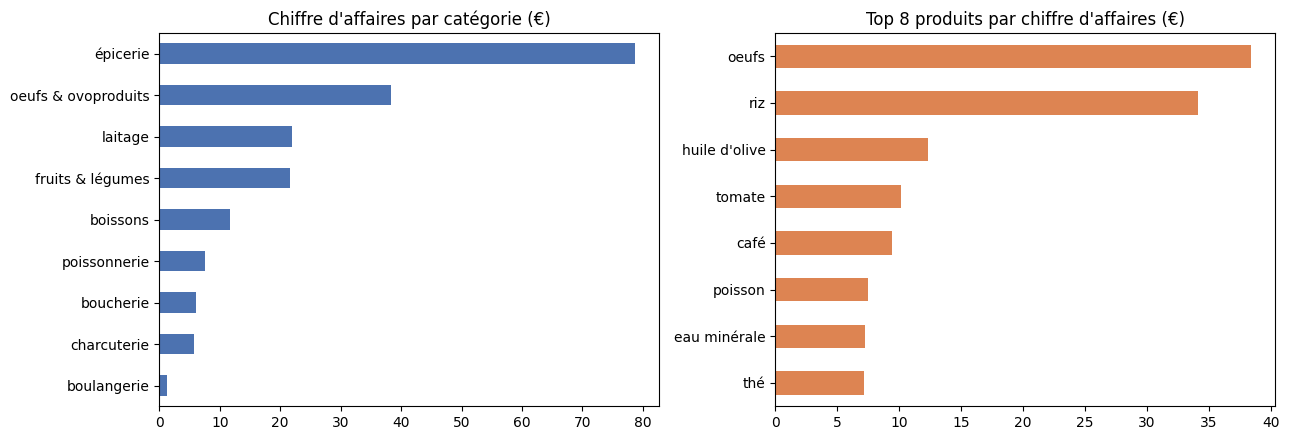

In [10]:
df["Montant"] = df["Quantité"] * df["Prix"]

ca_categorie = df.groupby("Catégorie")["Montant"].sum().sort_values()
print(f"Chiffre d'affaires total : {df['Montant'].sum():.2f} € sur {len(df)} transactions "
      f"(panier moyen {df['Montant'].mean():.2f} €)")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4.5))
ca_categorie.plot.barh(ax=ax0, color="#4C72B0")
ax0.set_title("Chiffre d'affaires par catégorie (€)")
ax0.set_ylabel("")
top = df.groupby("Produit")["Montant"].sum().nlargest(8).sort_values()
top.plot.barh(ax=ax1, color="#DD8452")
ax1.set_title("Top 8 produits par chiffre d'affaires (€)")
ax1.set_ylabel("")
plt.tight_layout()
plt.show()

In [11]:
ventes_jour = df.groupby(df["Date"].dt.date).agg(transactions=("TransactionID", "count"),
                                                  chiffre_affaires=("Montant", "sum"))
ventes_jour.round(2)

,transactions,chiffre_affaires
Date,,
2025-09-01,3,5.90
2025-09-02,4,12.84
2025-09-03,4,11.10
2025-09-04,4,51.89
2025-09-05,4,9.64
2025-09-06,5,13.55
2025-09-07,6,25.45
2025-09-08,1,2.80
2025-09-09,3,34.45


## Bilan

| Étape | Avant | Après |
|---|---|---|
| Transactions | 51 lignes brutes | 41 transactions fiables |
| Catégories | 22 libellés | 9 catégories |
| Produits | 40 libellés | 24 produits |
| Dates | formats mélangés, 28 jour/mois inversés | format unique `AAAA-MM-JJ`, du 1er au 12 septembre 2025 |
| Prix | 1 prix ×8 par rapport à la normale | corrigé par le prix médian du produit |
| Doubles saisies | 3 ventes ressaisies sous un autre identifiant | supprimées |

L'épicerie génère 41 % du chiffre d'affaires (78,72 € sur 192,87 €). Les œufs et le riz arrivent en tête des produits, portés par des achats en volume (plateau de 12 œufs, lot de 25 paquets de riz).

**Ce que montre ce projet :**
- un premier nettoyage « qui a l'air propre » peut encore contenir des erreurs silencieuses (dates inversées, doublons sous un autre identifiant) : il faut **relire le résultat**, pas seulement exécuter le pipeline ;
- chaque correction repose sur une règle explicite et justifiée, et les hypothèses non vérifiables (doubles saisies) sont documentées pour validation par le métier.